In [ ]:
import pandas as pd
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=columns
)

df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
#dataset dimensions

print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1372, 5)
Number of Rows: 1372
Number of Columns: 5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
print('Class distribution (counts):')
print(df['Class'].value_counts())
print('\nClass distribution (proportions):')
print(df['Class'].value_counts(normalize=True))

Class distribution (counts):
Class
0    762
1    610
Name: count, dtype: int64

Class distribution (proportions):
Class
0    0.555394
1    0.444606
Name: proportion, dtype: float64


TASK 2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Global styling: bold axis labels, tick labels, and legend text; 600 dpi exports
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'savefig.dpi': 600,
    'savefig.format': 'eps',
    'savefig.bbox': 'tight'
})


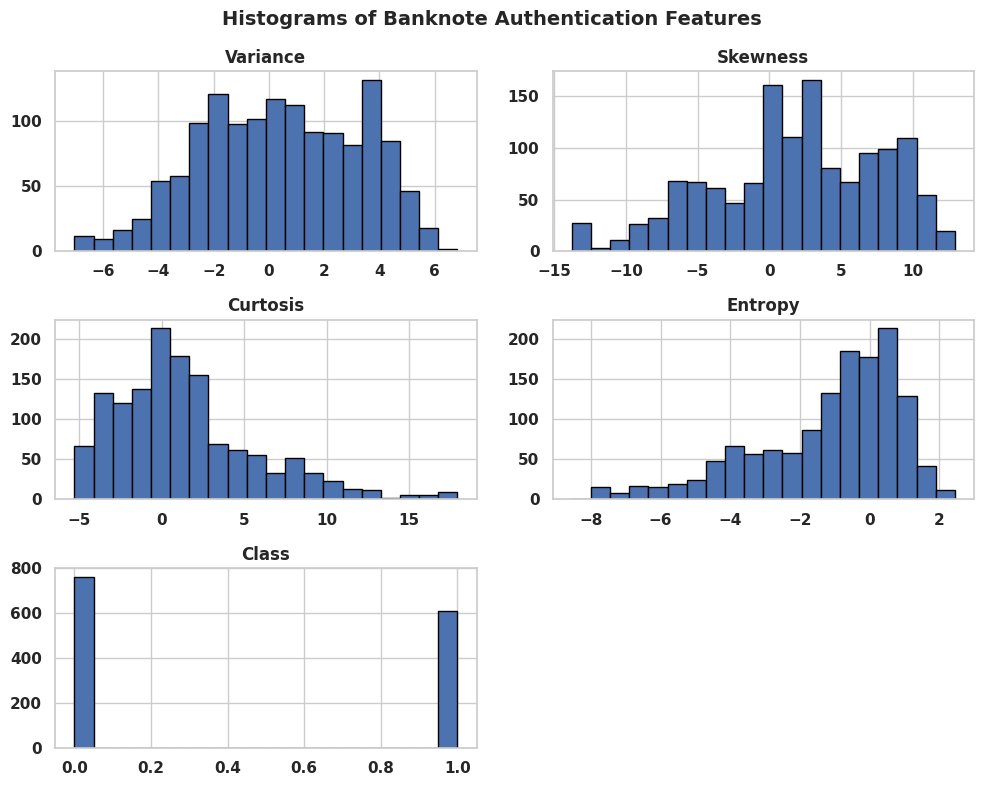

In [ ]:

df.hist(figsize=(10, 8), bins=20, edgecolor='black')

plt.suptitle("Histograms of Banknote Authentication Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("histograms.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


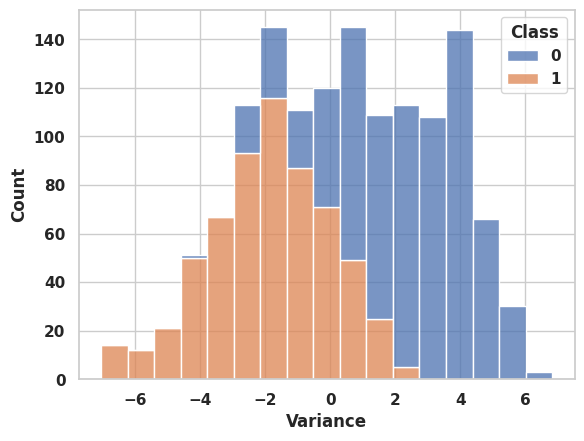

In [ ]:
sns.histplot(data=df,
             x='Variance',
             hue='Class',
             multiple='stack')
plt.savefig("variance_histplot_by_class.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


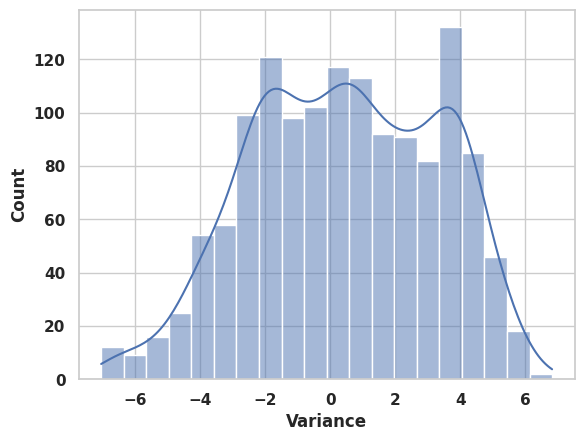

In [ ]:
sns.histplot(df['Variance'], bins=20, kde=True)
plt.savefig("variance_histplot_kde.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


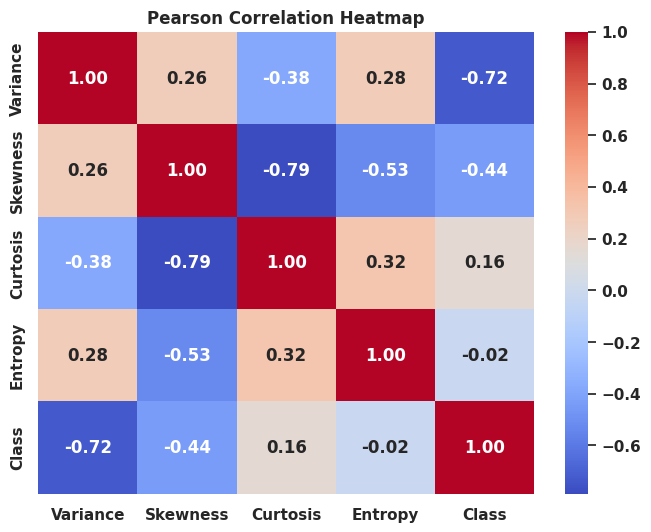

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(method='pearson'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Pearson Correlation Heatmap")
plt.savefig("correlation_heatmap.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


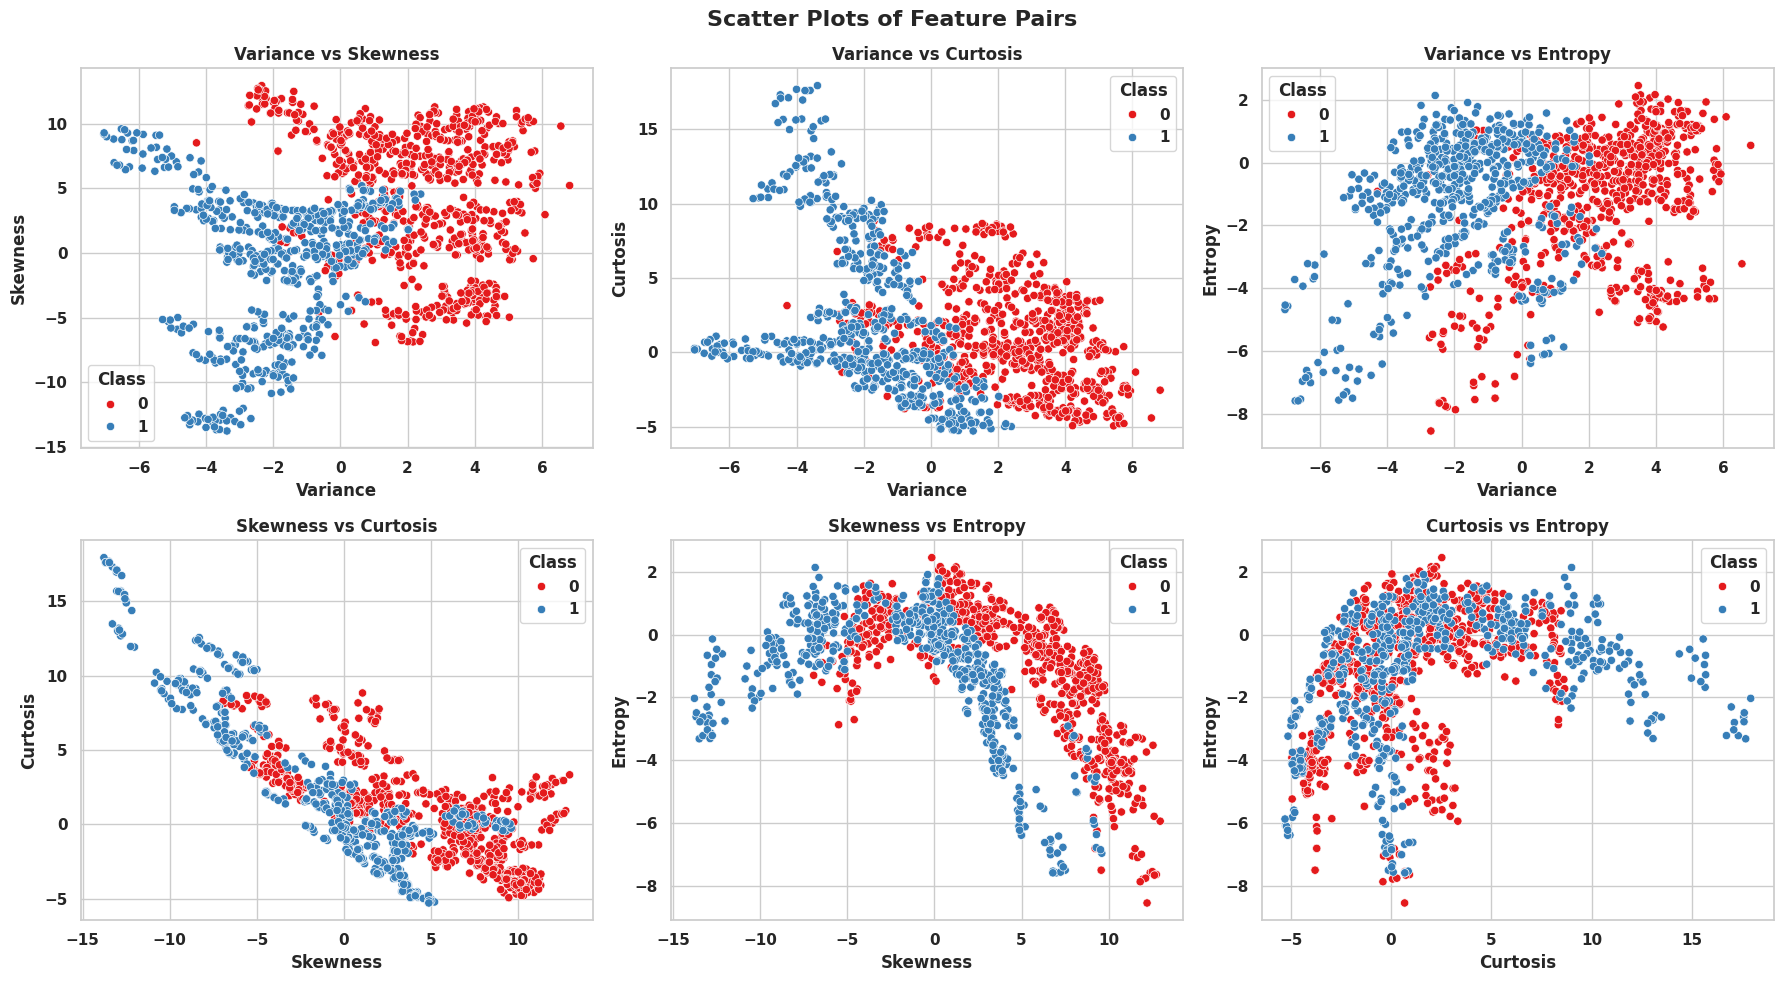

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Numerical feature names (updated to new names)
features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

# Generate all unique pairs
pairs = list(combinations(features, 2))

# Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot each scatter plot
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue='Class',  # Updated hue to 'Class'
        palette='Set1',
        ax=ax
    )
    ax.set_title(f'{x} vs {y}')
    ax.set_xlabel(x, fontweight='bold')
    ax.set_ylabel(y, fontweight='bold')
    leg = ax.legend(title='Class')
    plt.setp(leg.get_texts(), fontweight='bold')
    plt.setp(leg.get_title(), fontweight='bold')

plt.suptitle('Scatter Plots of Feature Pairs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("scatter_feature_pairs.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


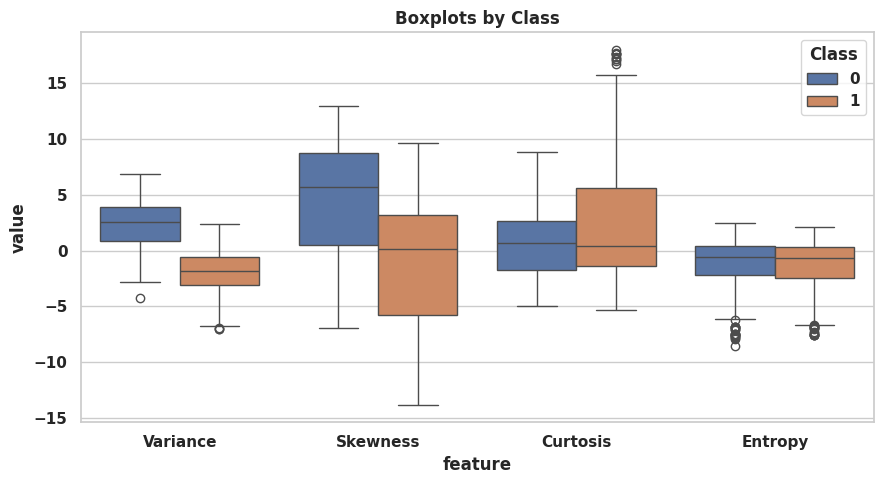

In [ ]:
plt.figure(figsize=(9, 5))
melted = df.melt(id_vars='Class', var_name="feature", value_name="value")
sns.boxplot(data=melted, x="feature", y="value", hue='Class')
plt.title("Boxplots by Class")
leg = plt.legend(title='Class')
plt.setp(leg.get_texts(), fontweight='bold')
plt.setp(leg.get_title(), fontweight='bold')
plt.tight_layout()
plt.savefig("boxplots_by_class.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns="Class").values
y = df["Class"].values

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=7,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (1097, 4)
Testing data shape: (275, 4)
Training labels shape: (1097,)
Testing labels shape: (275,)


In [ ]:
import numpy as np

print("\n===== TASK 4 & TASK 5: PERCEPTRON IMPLEMENTATION AND TRAINING =====")

# -------------------------------------------------
# Parameters
# -------------------------------------------------

learning_rate = 0.01
epochs = 50

# -------------------------------------------------
# Weight Initialization
# -------------------------------------------------

weights = np.zeros(X_train.shape[1])

# -------------------------------------------------
# Bias Initialization
# -------------------------------------------------

bias = 0

print("Initial Weights:", weights)
print("Initial Bias:", bias)

# Store training history (optional)
misclassified_history = []
weight_history = []
bias_history = []

# -------------------------------------------------
# Model Training
# -------------------------------------------------

for epoch in range(epochs):

    misclassified = 0

    # Train using every sample
    for i in range(len(X_train)):

        # -----------------------------
        # Forward Propagation
        # -----------------------------

        z = np.dot(X_train[i], weights) + bias

        # -----------------------------
        # Step Activation Function
        # -----------------------------

        if z >= 0:
            prediction = 1
        else:
            prediction = 0

        # -----------------------------
        # Perceptron Learning Rule
        # -----------------------------

        error = y_train[i] - prediction

        weights = weights + learning_rate * error * X_train[i]
        bias = bias + learning_rate * error

        if error != 0:
            misclassified += 1

    # Save history
    misclassified_history.append(misclassified)
    weight_history.append(weights.copy())
    bias_history.append(bias)

    # Display training progress
    print(f"\nEpoch {epoch + 1}")
    print("Misclassified Samples:", misclassified)
    print("Updated Weights:", weights)
    print("Updated Bias:", bias)

    # Stop if no errors remain
    if misclassified == 0:
        print("\nTraining Converged Successfully!")
        break


===== TASK 4 & TASK 5: PERCEPTRON IMPLEMENTATION AND TRAINING =====
Initial Weights: [0. 0. 0. 0.]
Initial Bias: 0

Epoch 1
Misclassified Samples: 53
Updated Weights: [-0.07172913 -0.06459747 -0.06394283  0.00440934]
Updated Bias: -0.03

Epoch 2
Misclassified Samples: 22
Updated Weights: [-0.07362142 -0.07571125 -0.07106102  0.00836357]
Updated Bias: -0.05

Epoch 3
Misclassified Samples: 37
Updated Weights: [-0.10137147 -0.11857167 -0.06506799 -0.00163016]
Updated Bias: -0.04

Epoch 4
Misclassified Samples: 18
Updated Weights: [-0.10705102 -0.12940634 -0.07142015  0.0009985 ]
Updated Bias: -0.04

Epoch 5
Misclassified Samples: 20
Updated Weights: [-0.10221135 -0.1239463  -0.10340289  0.00528526]
Updated Bias: -0.060000000000000005

Epoch 6
Misclassified Samples: 16
Updated Weights: [-0.11243158 -0.12818908 -0.11034737  0.00804979]
Updated Bias: -0.060000000000000005

Epoch 7
Misclassified Samples: 16
Updated Weights: [-0.11921661 -0.1247428  -0.12048208 -0.00988522]
Updated Bias: -0.0

In [ ]:
y_pred = []

for sample in X_test:

    z = np.dot(sample, weights) + bias

    if z >= 0:
        y_pred.append(1)
    else:
        y_pred.append(0)

y_pred = np.array(y_pred)


===== TASK 6: MODEL EVALUATION =====
Accuracy : 0.9636
Precision: 0.9308
Recall   : 0.9918
F1-score : 0.9603

Confusion Matrix:
[[144   9]
 [  1 121]]


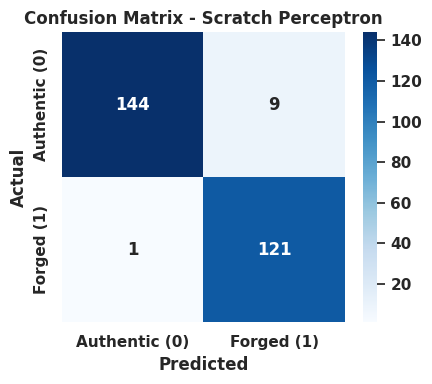

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n===== TASK 6: MODEL EVALUATION =====")

# -----------------------------------
# Prediction on Test Data
# -----------------------------------

y_pred = []

for sample in X_test:

    z = np.dot(sample, weights) + bias

    if z >= 0:
        y_pred.append(1)
    else:
        y_pred.append(0)

y_pred = np.array(y_pred)


# -----------------------------------
# Evaluation Metrics
# -----------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(y_test, y_pred)


# -----------------------------------
# Display Results
# -----------------------------------

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)


# -----------------------------------
# Confusion Matrix Visualization
# -----------------------------------

plt.figure(figsize=(4.5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Authentic (0)", "Forged (1)"],
    yticklabels=["Authentic (0)", "Forged (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Scratch Perceptron")

plt.tight_layout()
plt.show()

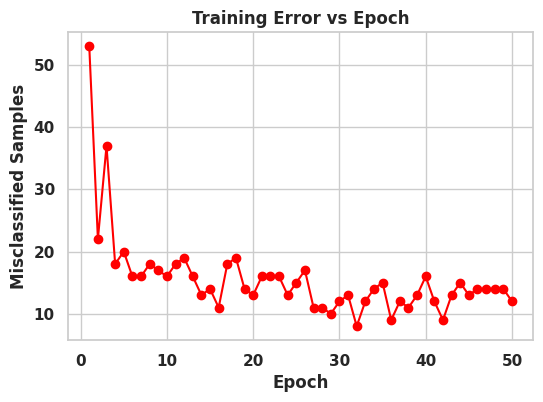

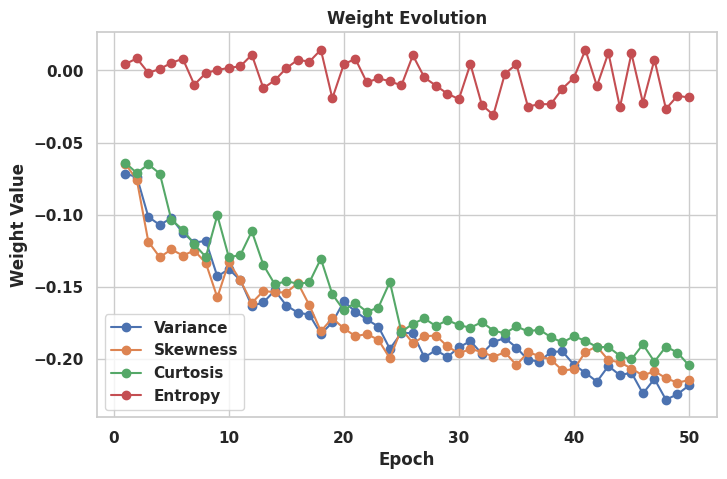

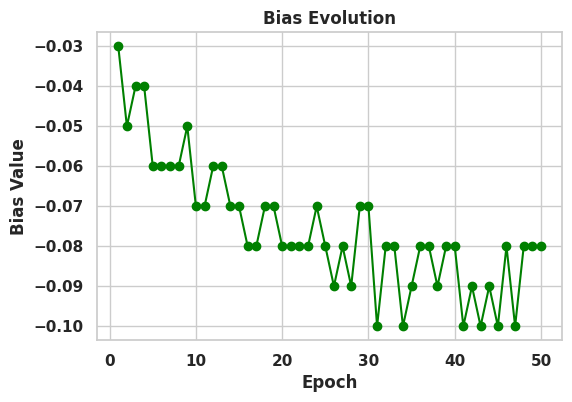

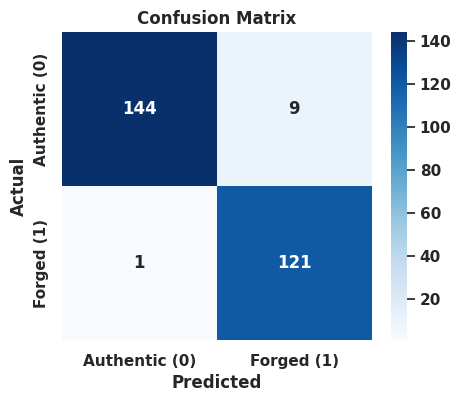

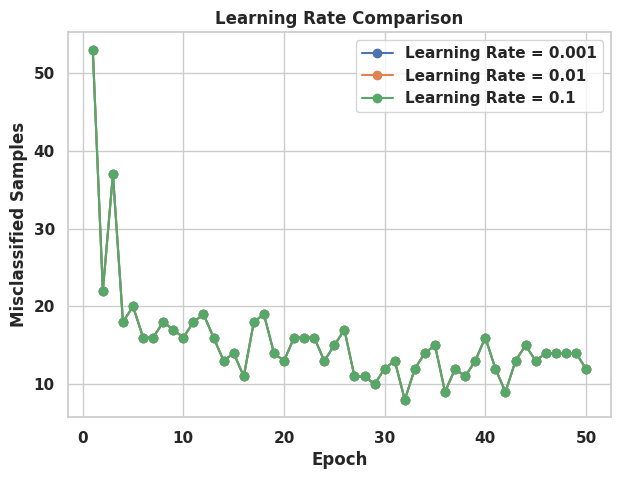

In [ ]:
# ============================================================
# ADDITIONAL ANALYSIS AND VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# ============================================================
# 1. Training Error vs Epoch
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(misclassified_history)+1),
    misclassified_history,
    marker='o',
    color='red'
)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)

plt.savefig("training_error_vs_epoch.png", format="png", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 2. Weight Evolution
# ============================================================

weight_history_array = np.array(weight_history)

feature_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy"
]

plt.figure(figsize=(8,5))

for i in range(weight_history_array.shape[1]):

    plt.plot(
        range(1, len(weight_history_array)+1),
        weight_history_array[:,i],
        marker='o',
        label=feature_names[i]
    )


plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
leg = plt.legend()
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)

plt.savefig("weight_evolution.png", format="png", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 3. Bias Evolution
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(bias_history)+1),
    bias_history,
    marker='o',
    color='green'
)

plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(True)

plt.savefig("bias_evolution.png", format="png", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 4. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Authentic (0)",
        "Forged (1)"
    ],
    yticklabels=[
        "Authentic (0)",
        "Forged (1)"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", format="png", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 5. Learning Rate Comparison
# ============================================================

learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(7,5))


for lr in learning_rates:

    temp_weights = np.zeros(X_train.shape[1])
    temp_bias = 0

    error_history = []


    for epoch in range(50):

        errors = 0


        for i in range(len(X_train)):

            z = np.dot(
                X_train[i],
                temp_weights
            ) + temp_bias


            prediction = 1 if z >= 0 else 0


            error = y_train[i] - prediction


            temp_weights += (
                lr * error * X_train[i]
            )

            temp_bias += lr * error


            if error != 0:
                errors += 1


        error_history.append(errors)



    plt.plot(
        range(1,51),
        error_history,
        marker='o',
        label=f"Learning Rate = {lr}"
    )


plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
leg = plt.legend()
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)

plt.savefig("learning_rate_comparison.png", format="png", dpi=600, bbox_inches="tight")
plt.show()



# ============================================================
# 6. Decision Boundary (Using Variance and Skewness)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Select two features
X_boundary = df[
    ["Variance","Skewness"]
].values

y_boundary = df["Class"].values


# Normalize
scaler = StandardScaler()

X_boundary = scaler.fit_transform(
    X_boundary
)


# Initialize parameters

boundary_weights = np.zeros(2)
boundary_bias = 0

lr = 0.01


# Train perceptron on two features

for epoch in range(50):

    for i in range(len(X_boundary)):

        z = np.dot(
            X_boundary[i],
            boundary_weights
        ) + boundary_bias


        prediction = 1 if z >= 0 else 0


        error = y_boundary[i] - prediction


        boundary_weights += (
            lr * error * X_boundary[i]
        )

        boundary_bias += lr * error





===== OPTIONAL: DECISION BOUNDARY VISUALIZATION =====


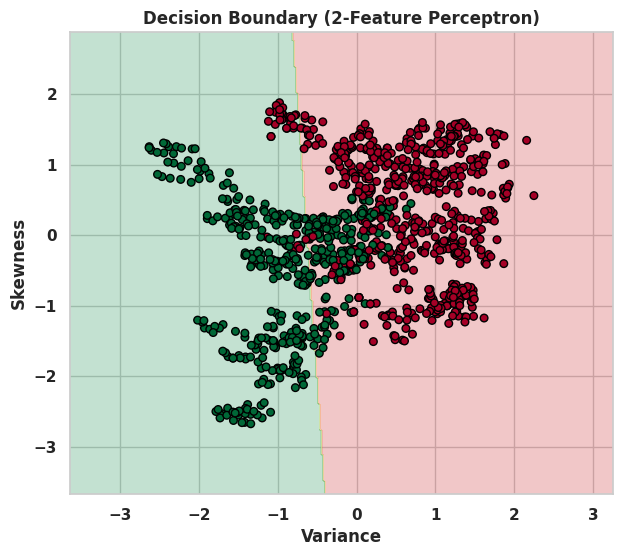

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\n===== OPTIONAL: DECISION BOUNDARY VISUALIZATION =====")

# -------------------------------------------------
# Select two features
# 0 -> Variance
# 1 -> Skewness
# -------------------------------------------------

feature_idx = (0, 1)

X2 = X_train[:, feature_idx]


# -------------------------------------------------
# Initialize perceptron parameters
# -------------------------------------------------

eta = 0.01
n_epochs = 50

weights_2 = np.zeros(2)
bias_2 = 0


# -------------------------------------------------
# Train 2-feature perceptron
# -------------------------------------------------

for epoch in range(n_epochs):

    errors = 0

    for i in range(len(X2)):

        # Forward propagation
        z = np.dot(X2[i], weights_2) + bias_2

        # Step activation
        prediction = 1 if z >= 0 else 0

        # Error
        error = y_train[i] - prediction

        # Perceptron learning rule
        weights_2 += eta * error * X2[i]
        bias_2 += eta * error

        if error != 0:
            errors += 1


    if errors == 0:
        break



# -------------------------------------------------
# Create mesh grid for decision regions
# -------------------------------------------------

x_min = X2[:,0].min() - 1
x_max = X2[:,0].max() + 1

y_min = X2[:,1].min() - 1
y_max = X2[:,1].max() + 1


xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)


# Predict grid points

grid = np.c_[xx.ravel(), yy.ravel()]

grid_predictions = []


for point in grid:

    z = np.dot(point, weights_2) + bias_2

    if z >= 0:
        grid_predictions.append(1)
    else:
        grid_predictions.append(0)


grid_predictions = np.array(grid_predictions)

grid_predictions = grid_predictions.reshape(xx.shape)



# -------------------------------------------------
# Plot decision boundary
# -------------------------------------------------

plt.figure(figsize=(7,6))


# Decision regions
plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.25,
    cmap="RdYlGn"
)


# Training samples
plt.scatter(
    X2[:,0],
    X2[:,1],
    c=y_train,
    cmap="RdYlGn",
    edgecolor="black",
    s=30
)


plt.xlabel("Variance")
plt.ylabel("Skewness")

plt.title(
    "Decision Boundary (2-Feature Perceptron)"
)

plt.grid(True)

plt.savefig("decision_boundary.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
import pandas as pd

# ================================
# TRAINING SUMMARY
# ================================

print("\n===== TRAINING SUMMARY =====")

summary = pd.DataFrame({
    "Parameter": [
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        len(df),
        "80% / 20%",
        learning_rate,
        len(misclassified_history),
        str(np.round(weights, 4)),
        round(bias, 4),
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ]
})

print(summary.to_string(index=False))


===== TRAINING SUMMARY =====
       Parameter                             Value
    Dataset Size                              1372
Train/Test Split                         80% / 20%
   Learning Rate                              0.01
          Epochs                                50
   Final Weights [-0.2182 -0.2145 -0.2043 -0.0187]
      Final Bias                             -0.08
        Accuracy                            0.9636
       Precision                            0.9308
          Recall                            0.9918
        F1-score                            0.9603


In [ ]:
# ================================
# EPOCH-WISE LEARNING
# ================================

epoch_table = []

for i in range(len(misclassified_history)):

    epoch_table.append([
        i + 1,
        misclassified_history[i],
        weight_history[i][0],
        weight_history[i][1],
        bias_history[i]
    ])


epoch_df = pd.DataFrame(
    epoch_table,
    columns=[
        "Epoch",
        "Errors",
        "Weight 1",
        "Weight 2",
        "Bias"
    ]
)

print("\n===== EPOCH-WISE LEARNING =====")

print(
    epoch_df.round(4).to_string(index=False)
)


===== EPOCH-WISE LEARNING =====
 Epoch  Errors  Weight 1  Weight 2  Bias
     1      53   -0.0717   -0.0646 -0.03
     2      22   -0.0736   -0.0757 -0.05
     3      37   -0.1014   -0.1186 -0.04
     4      18   -0.1071   -0.1294 -0.04
     5      20   -0.1022   -0.1239 -0.06
     6      16   -0.1124   -0.1282 -0.06
     7      16   -0.1192   -0.1247 -0.06
     8      18   -0.1181   -0.1334 -0.06
     9      17   -0.1427   -0.1573 -0.05
    10      16   -0.1376   -0.1329 -0.07
    11      18   -0.1452   -0.1454 -0.07
    12      19   -0.1631   -0.1610 -0.06
    13      16   -0.1607   -0.1528 -0.06
    14      13   -0.1524   -0.1535 -0.07
    15      14   -0.1628   -0.1539 -0.07
    16      11   -0.1678   -0.1472 -0.08
    17      18   -0.1692   -0.1626 -0.08
    18      19   -0.1825   -0.1806 -0.07
    19      14   -0.1746   -0.1717 -0.07
    20      13   -0.1600   -0.1786 -0.08
    21      16   -0.1670   -0.1841 -0.08
    22      16   -0.1725   -0.1826 -0.08
    23      16   -0.1774

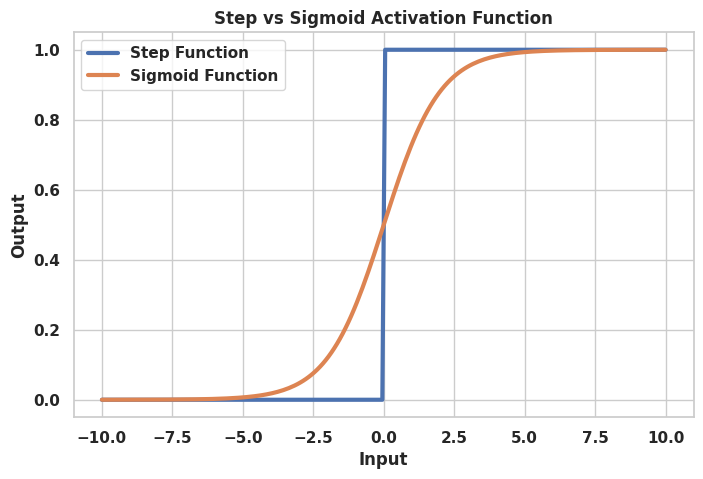

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Input range
x = np.linspace(-10, 10, 200)


# Step Activation Function
step_output = np.where(x >= 0, 1, 0)


# Sigmoid Activation Function
sigmoid_output = 1 / (1 + np.exp(-x))


# Plot
plt.figure(figsize=(8,5))

plt.plot(
    x,
    step_output,
    label="Step Function",
    linewidth=3
)

plt.plot(
    x,
    sigmoid_output,
    label="Sigmoid Function",
    linewidth=3
)

plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Step vs Sigmoid Activation Function")

leg = plt.legend()
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)

plt.savefig("step_vs_sigmoid_activation.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

In [ ]:
# Create sklearn perceptron

sk_model = Perceptron(
    eta0=0.01,
    max_iter=50,
    random_state=7
)


# Train

sk_model.fit(
    X_train,
    y_train
)


# Prediction

sk_pred = sk_model.predict(
    X_test
)


# Accuracy

sk_accuracy = accuracy_score(
    y_test,
    sk_pred
)


print("Scikit-learn Perceptron Accuracy:",
      sk_accuracy)


print("\nScikit-learn Weights:")
print(sk_model.coef_)


print("\nScikit-learn Bias:")
print(sk_model.intercept_)

Scikit-learn Perceptron Accuracy: 0.9454545454545454

Scikit-learn Weights:
[[-0.12890256 -0.13029207 -0.08368971 -0.00935735]]

Scikit-learn Bias:
[-0.03]


In [ ]:
print("\nScratch Perceptron Accuracy:",
      accuracy)


print("\nScratch Weights:")
print(weights)


print("\nScratch Bias:")
print(bias)


Scratch Perceptron Accuracy: 0.9636363636363636

Scratch Weights:
[-0.21822076 -0.21445339 -0.20429861 -0.01871864]

Scratch Bias:
-0.08


In [ ]:
import numpy as np


# XOR dataset

X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])


y_xor = np.array([
    0,
    1,
    1,
    0
])


# Initialize

weights_xor = np.zeros(2)

bias_xor = 0

lr = 0.1


# Training

for epoch in range(20):

    errors = 0


    for i in range(len(X_xor)):


        z = (
            np.dot(
                X_xor[i],
                weights_xor
            )
            +
            bias_xor
        )


        prediction = (
            1 if z >= 0
            else 0
        )


        error = (
            y_xor[i]
            -
            prediction
        )


        weights_xor += (
            lr *
            error *
            X_xor[i]
        )


        bias_xor += (
            lr *
            error
        )


        if error != 0:
            errors += 1


    print(
        "Epoch:",
        epoch+1,
        "Errors:",
        errors
    )


print("\nFinal Weights:")
print(weights_xor)

print("Final Bias:")
print(bias_xor)

Epoch: 1 Errors: 3
Epoch: 2 Errors: 3
Epoch: 3 Errors: 4
Epoch: 4 Errors: 4
Epoch: 5 Errors: 4
Epoch: 6 Errors: 4
Epoch: 7 Errors: 4
Epoch: 8 Errors: 4
Epoch: 9 Errors: 4
Epoch: 10 Errors: 4
Epoch: 11 Errors: 4
Epoch: 12 Errors: 4
Epoch: 13 Errors: 4
Epoch: 14 Errors: 4
Epoch: 15 Errors: 4
Epoch: 16 Errors: 4
Epoch: 17 Errors: 4
Epoch: 18 Errors: 4
Epoch: 19 Errors: 4
Epoch: 20 Errors: 4

Final Weights:
[-0.1  0. ]
Final Bias:
0.0


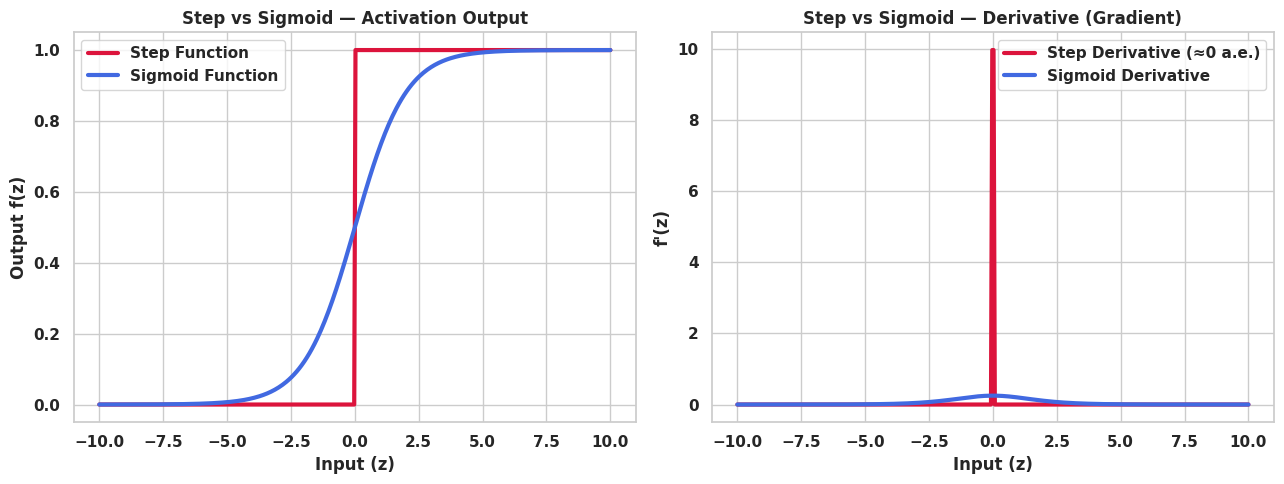

Max |gradient| of Step function (excluding the discontinuity point): 0.0
Max gradient of Sigmoid function: 0.25 (occurs at z = 0)


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

step_output = np.where(x >= 0, 1, 0)
sigmoid_output = 1 / (1 + np.exp(-x))

# Numerical derivatives (step has a Dirac-delta-like spike, effectively 0 a.e.)
step_derivative = np.gradient(step_output, x)
sigmoid_derivative = sigmoid_output * (1 - sigmoid_output)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Activation functions ---
axes[0].plot(x, step_output, label="Step Function", linewidth=3, color="crimson")
axes[0].plot(x, sigmoid_output, label="Sigmoid Function", linewidth=3, color="royalblue")
axes[0].set_title("Step vs Sigmoid — Activation Output", fontweight='bold')
axes[0].set_xlabel("Input (z)")
axes[0].set_ylabel("Output f(z)")
axes[0].grid(True)
leg = axes[0].legend()
plt.setp(leg.get_texts(), fontweight='bold')

# --- Derivatives ---
axes[1].plot(x, step_derivative, label="Step Derivative (≈0 a.e.)", linewidth=3, color="crimson")
axes[1].plot(x, sigmoid_derivative, label="Sigmoid Derivative", linewidth=3, color="royalblue")
axes[1].set_title("Step vs Sigmoid — Derivative (Gradient)", fontweight='bold')
axes[1].set_xlabel("Input (z)")
axes[1].set_ylabel("f'(z)")
axes[1].grid(True)
leg2 = axes[1].legend()
plt.setp(leg2.get_texts(), fontweight='bold')

plt.tight_layout()
plt.savefig("step_vs_sigmoid_full_comparison.png", format="png", dpi=600, bbox_inches="tight")
plt.show()

print("Max |gradient| of Step function (excluding the discontinuity point):",
      round(float(np.max(np.abs(step_derivative[np.abs(x) > 0.05]))), 6))
print("Max gradient of Sigmoid function:", round(float(np.max(sigmoid_derivative)), 4),
      "(occurs at z = 0)")


In [ ]:

import pandas as pd

comparison_table = pd.DataFrame({
    "Property": [
        "Output range",
        "Continuity",
        "Differentiable everywhere?",
        "Gradient value (typical)",
        "Output type",
        "Sensitivity near decision boundary",
        "Usable with backpropagation?",
        "Typical use today"
    ],
    "Step Function": [
        "{0, 1} (binary / discrete)",
        "Discontinuous at z = 0",
        "No (undefined at 0, derivative = 0 elsewhere)",
        "0 almost everywhere",
        "Hard / crisp decision",
        "None — infinitesimally small change in z never changes gradient",
        "No — gradient descent gets no learning signal",
        "Classic single-layer Perceptron only"
    ],
    "Sigmoid Function": [
        "(0, 1) (continuous)",
        "Continuous everywhere",
        "Yes, smooth and differentiable",
        "Up to 0.25 (at z = 0), smoothly decays",
        "Soft probability-like score",
        "High — output changes smoothly with z",
        "Yes — non-zero gradient everywhere enables weight updates",
        "Output layer for binary classification, gates in LSTMs, etc."
    ]
})

print(comparison_table.to_string(index=False))
comparison_table


                          Property                                                   Step Function                                             Sigmoid Function
                      Output range                                      {0, 1} (binary / discrete)                                          (0, 1) (continuous)
                        Continuity                                          Discontinuous at z = 0                                        Continuous everywhere
        Differentiable everywhere?                   No (undefined at 0, derivative = 0 elsewhere)                               Yes, smooth and differentiable
          Gradient value (typical)                                             0 almost everywhere                       Up to 0.25 (at z = 0), smoothly decays
                       Output type                                           Hard / crisp decision                                  Soft probability-like score
Sensitivity near decision boundary None 

,Property,Step Function,Sigmoid Function
0,Output range,"{0, 1} (binary / discrete)","(0, 1) (continuous)"
1,Continuity,Discontinuous at z = 0,Continuous everywhere
2,Differentiable everywhere?,"No (undefined at 0, derivative = 0 elsewhere)","Yes, smooth and differentiable"
3,Gradient value (typical),0 almost everywhere,"Up to 0.25 (at z = 0), smoothly decays"
4,Output type,Hard / crisp decision,Soft probability-like score
5,Sensitivity near decision boundary,None — infinitesimally small change in z never...,High — output changes smoothly with z
6,Usable with backpropagation?,No — gradient descent gets no learning signal,Yes — non-zero gradient everywhere enables wei...
7,Typical use today,Classic single-layer Perceptron only,"Output layer for binary classification, gates ..."


In [ ]:

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train scikit-learn's Perceptron under matched settings ---
sk_model = Perceptron(eta0=learning_rate, max_iter=len(misclassified_history), random_state=7)
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

sk_accuracy  = accuracy_score(y_test, sk_pred)
sk_precision = precision_score(y_test, sk_pred, zero_division=0)
sk_recall    = recall_score(y_test, sk_pred, zero_division=0)
sk_f1        = f1_score(y_test, sk_pred, zero_division=0)
sk_cm        = confusion_matrix(y_test, sk_pred)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Scratch Perceptron": [accuracy, precision, recall, f1],
    "Scikit-learn Perceptron": [sk_accuracy, sk_precision, sk_recall, sk_f1]
})
print(metrics_table.round(4).to_string(index=False))

weights_table = pd.DataFrame({
    "Feature": feature_names,
    "Scratch Weight": np.round(weights, 4),
    "Scikit-learn Weight": np.round(sk_model.coef_.flatten(), 4)
})
weights_table.loc[len(weights_table)] = ["Bias", round(bias, 4), round(float(sk_model.intercept_[0]), 4)]
print("\n" + weights_table.to_string(index=False))


   Metric  Scratch Perceptron  Scikit-learn Perceptron
 Accuracy              0.9636                   0.9455
Precision              0.9308                   0.9280
   Recall              0.9918                   0.9508
 F1-score              0.9603                   0.9393

 Feature  Scratch Weight  Scikit-learn Weight
Variance         -0.2182              -0.1289
Skewness         -0.2145              -0.1303
Curtosis         -0.2043              -0.0837
 Entropy         -0.0187              -0.0094
    Bias         -0.0800              -0.0300


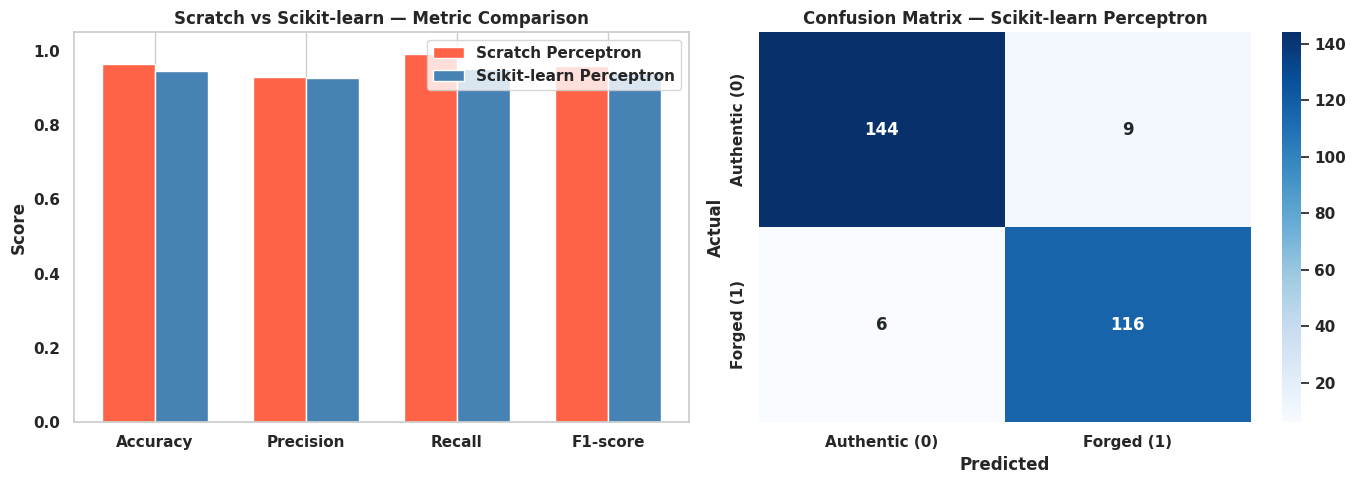

In [ ]:

# --- Visual comparison: grouped bar chart of metrics ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
scratch_vals = [accuracy, precision, recall, f1]
sk_vals = [sk_accuracy, sk_precision, sk_recall, sk_f1]

x_pos = np.arange(len(metric_names))
width = 0.35

axes[0].bar(x_pos - width/2, scratch_vals, width, label="Scratch Perceptron", color="tomato")
axes[0].bar(x_pos + width/2, sk_vals, width, label="Scikit-learn Perceptron", color="steelblue")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score")
axes[0].set_title("Scratch vs Scikit-learn — Metric Comparison", fontweight='bold')
leg = axes[0].legend()
plt.setp(leg.get_texts(), fontweight='bold')
axes[0].grid(axis='y')

# --- Confusion matrices side-by-side ---
sns.heatmap(sk_cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Authentic (0)", "Forged (1)"],
            yticklabels=["Authentic (0)", "Forged (1)"])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix — Scikit-learn Perceptron", fontweight='bold')

plt.tight_layout()
plt.savefig("scratch_vs_sklearn_comparison.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


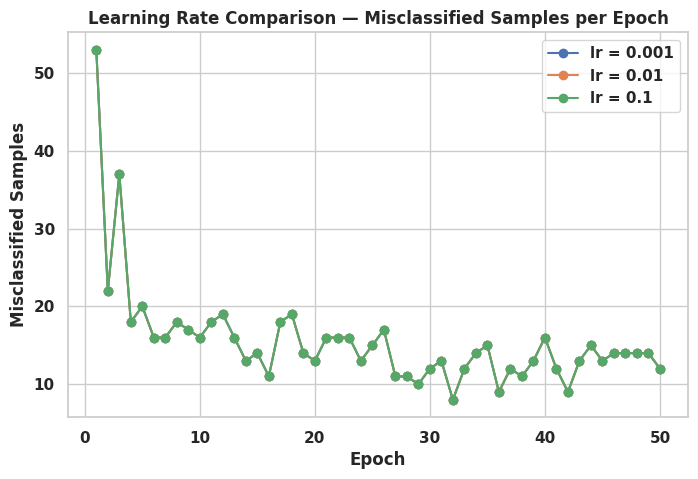

 Learning Rate  Epochs to Converge (or cap)  Final Test Accuracy
         0.001                           50               0.9636
         0.010                           50               0.9636
         0.100                           50               0.9636


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def train_perceptron(X_tr, y_tr, lr, epochs=50):
    w = np.zeros(X_tr.shape[1])
    b = 0.0
    history = []
    for epoch in range(epochs):
        errors = 0
        for i in range(len(X_tr)):
            z = np.dot(X_tr[i], w) + b
            pred = 1 if z >= 0 else 0
            err = y_tr[i] - pred
            w = w + lr * err * X_tr[i]
            b = b + lr * err
            if err != 0:
                errors += 1
        history.append(errors)
        if errors == 0:
            break
    return w, b, history

def evaluate(w, b, X_te, y_te):
    preds = np.array([1 if (np.dot(x, w) + b) >= 0 else 0 for x in X_te])
    return (preds == y_te).mean()

learning_rates = [0.001, 0.01, 0.1]
lr_results = {}

plt.figure(figsize=(8, 5))
for lr in learning_rates:
    w_lr, b_lr, hist = train_perceptron(X_train, y_train, lr, epochs=50)
    test_acc = evaluate(w_lr, b_lr, X_test, y_test)
    lr_results[lr] = {
        "weights": w_lr, "bias": b_lr, "history": hist,
        "epochs_to_converge": len(hist), "test_accuracy": test_acc
    }
    plt.plot(range(1, len(hist) + 1), hist, marker='o', label=f"lr = {lr}")

plt.title("Learning Rate Comparison — Misclassified Samples per Epoch", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
leg = plt.legend()
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)
plt.savefig("lr_comparison_detailed.png", format="png", dpi=600, bbox_inches="tight")
plt.show()

lr_summary = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Epochs to Converge (or cap)": [lr_results[lr]["epochs_to_converge"] for lr in learning_rates],
    "Final Test Accuracy": [round(lr_results[lr]["test_accuracy"], 4) for lr in learning_rates]
})
print(lr_summary.to_string(index=False))


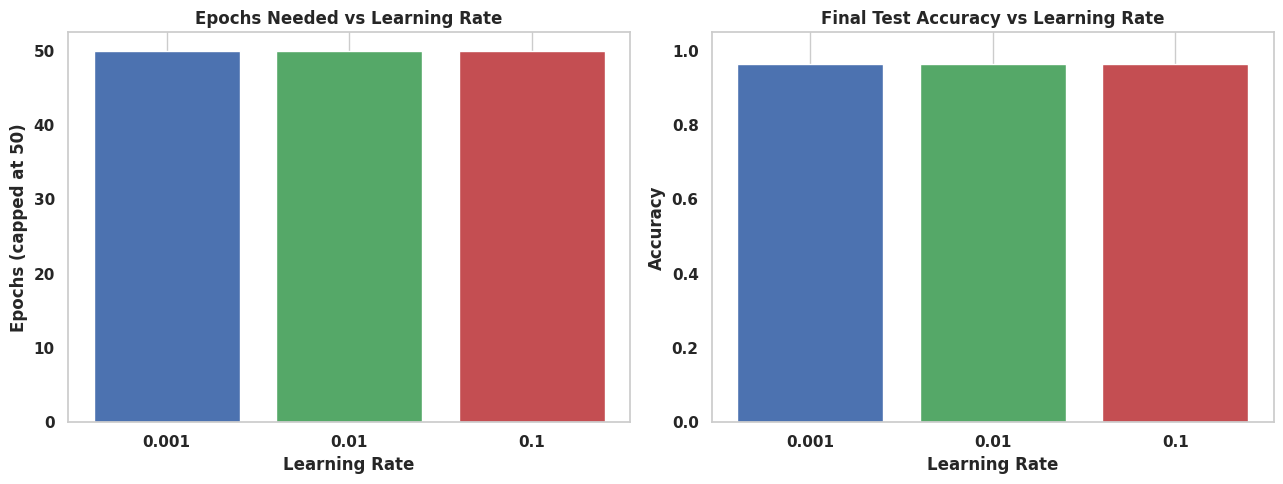

In [ ]:

# --- Bar chart: epochs to converge & final accuracy, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lr_labels = [str(lr) for lr in learning_rates]
epochs_needed = [lr_results[lr]["epochs_to_converge"] for lr in learning_rates]
accs = [lr_results[lr]["test_accuracy"] for lr in learning_rates]

axes[0].bar(lr_labels, epochs_needed, color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_title("Epochs Needed vs Learning Rate", fontweight='bold')
axes[0].set_xlabel("Learning Rate")
axes[0].set_ylabel("Epochs (capped at 50)")
axes[0].grid(axis='y')

axes[1].bar(lr_labels, accs, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Final Test Accuracy vs Learning Rate", fontweight='bold')
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("Accuracy")
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig("lr_bar_comparison.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


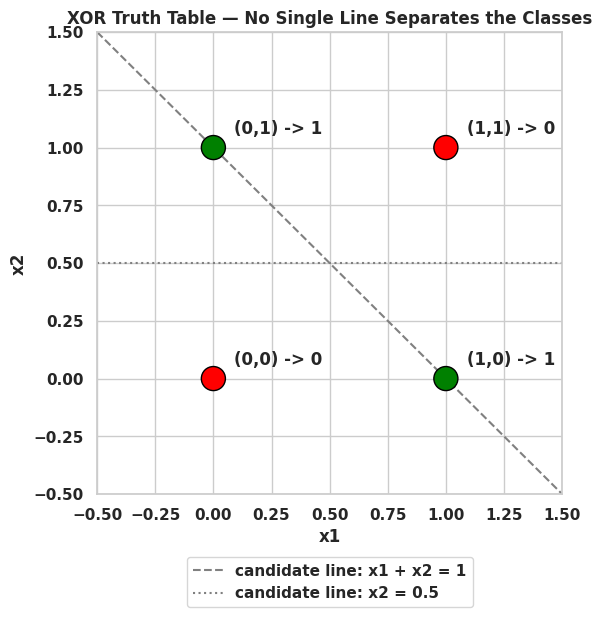

Class 0 points (red): [[0, 0], [1, 1]]
Class 1 points (green): [[0, 1], [1, 0]]

Notice: the two Class-1 points (0,1) and (1,0) sit on one diagonal, while the two
Class-0 points (0,0) and (1,1) sit on the OTHER diagonal — any straight line that puts
both green points on one side inevitably puts at least one red point on the same side.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

plt.figure(figsize=(6, 6))
colors = ['red' if label == 0 else 'green' for label in y_xor]
plt.scatter(X_xor[:,0], X_xor[:,1], c=colors, s=300, edgecolor='black', zorder=3)

for (x1, x2), label in zip(X_xor, y_xor):
    plt.annotate(f"({x1},{x2}) -> {label}", (x1, x2), textcoords="offset points",
                 xytext=(15, 10), fontweight='bold')

# A few candidate separating lines — none of them work
xs = np.linspace(-0.5, 1.5, 100)
plt.plot(xs, 1 - xs, '--', color='gray', label="candidate line: x1 + x2 = 1")
plt.plot(xs, [0.5]*len(xs), ':', color='gray', label="candidate line: x2 = 0.5")

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR Truth Table — No Single Line Separates the Classes", fontweight='bold')
leg = plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=1)
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)
plt.savefig("xor_not_linearly_separable.png", format="png", dpi=600, bbox_inches="tight")
plt.show()

print("Class 0 points (red):", X_xor[y_xor == 0].tolist())
print("Class 1 points (green):", X_xor[y_xor == 1].tolist())
print("\nNotice: the two Class-1 points (0,1) and (1,0) sit on one diagonal, while the two")
print("Class-0 points (0,0) and (1,1) sit on the OTHER diagonal — any straight line that puts")
print("both green points on one side inevitably puts at least one red point on the same side.")


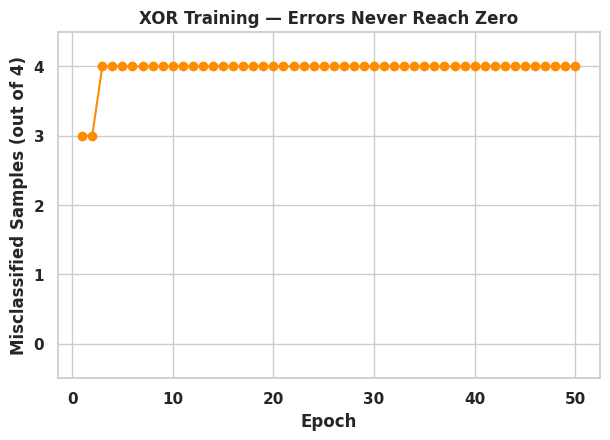

Final weights: [-0.1  0. ]
Final bias: 0.0
Minimum errors ever reached: 3 out of 4 samples
The perceptron oscillates between weight vectors forever and never finds a
separating line, because — as shown above — none exists.


In [ ]:

# --- Train a scratch perceptron on XOR and show it fails to converge ---
weights_xor = np.zeros(2)
bias_xor = 0.0
lr = 0.1
xor_error_history = []

for epoch in range(50):
    errors = 0
    for i in range(len(X_xor)):
        z = np.dot(X_xor[i], weights_xor) + bias_xor
        prediction = 1 if z >= 0 else 0
        error = y_xor[i] - prediction
        weights_xor += lr * error * X_xor[i]
        bias_xor += lr * error
        if error != 0:
            errors += 1
    xor_error_history.append(errors)

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(xor_error_history) + 1), xor_error_history, marker='o', color='darkorange')
plt.title("XOR Training — Errors Never Reach Zero", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples (out of 4)")
plt.ylim(-0.5, 4.5)
plt.grid(True)
plt.savefig("xor_error_never_converges.png", format="png", dpi=600, bbox_inches="tight")
plt.show()

print("Final weights:", weights_xor)
print("Final bias:", bias_xor)
print("Minimum errors ever reached:", min(xor_error_history), "out of 4 samples")
print("The perceptron oscillates between weight vectors forever and never finds a")
print("separating line, because — as shown above — none exists.")


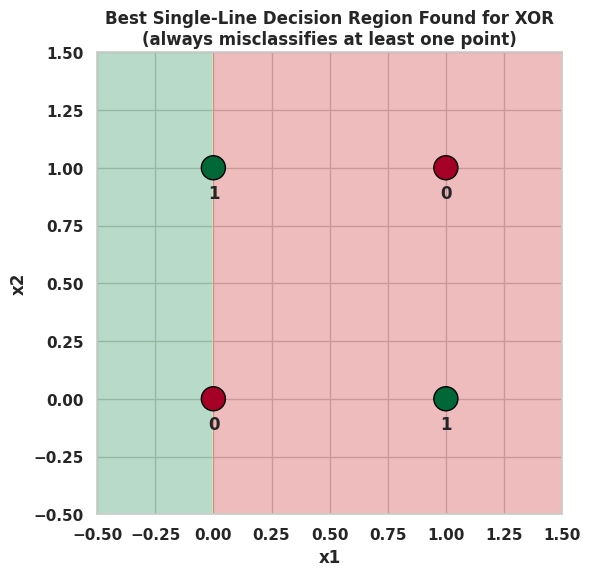

In [ ]:

# --- Decision-region plot using the (non-converged) final weights ---
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_pred = np.array([1 if (np.dot(p, weights_xor) + bias_xor) >= 0 else 0 for p in grid])
grid_pred = grid_pred.reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, grid_pred, alpha=0.3, cmap="RdYlGn")
plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor, cmap="RdYlGn", s=300, edgecolor="black", zorder=3)
for (x1, x2), label in zip(X_xor, y_xor):
    plt.annotate(str(label), (x1, x2), textcoords="offset points", xytext=(-4, -22), fontweight='bold')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Best Single-Line Decision Region Found for XOR\n(always misclassifies at least one point)", fontweight='bold')
plt.grid(True)
plt.savefig("xor_decision_region.png", format="png", dpi=600, bbox_inches="tight")
plt.show()


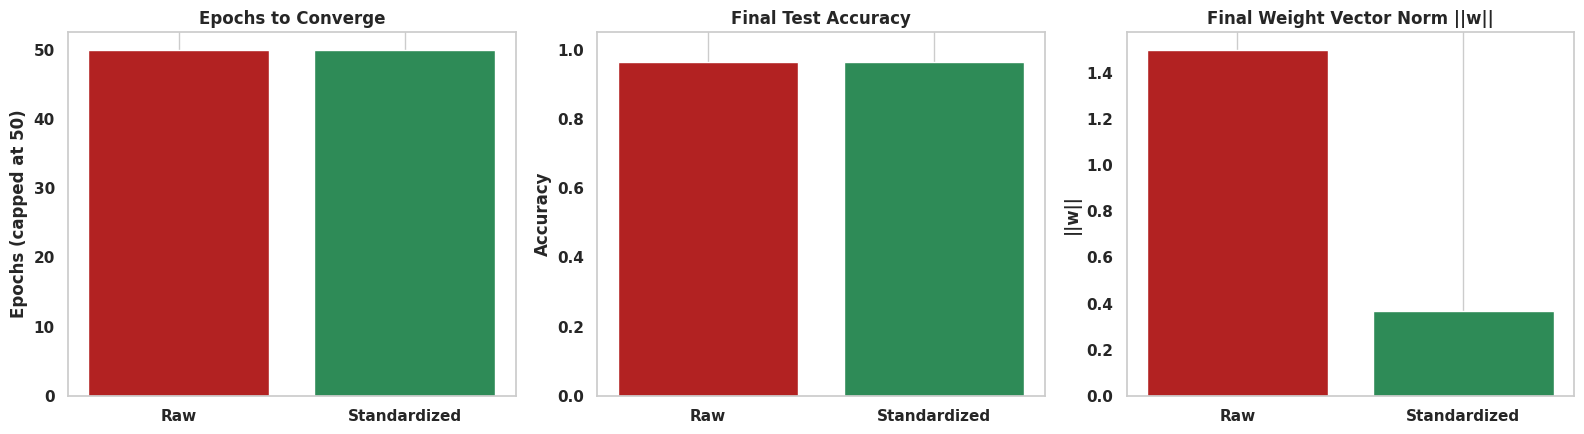

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def train_perceptron_track(X_tr, y_tr, lr=0.01, epochs=50):
    w = np.zeros(X_tr.shape[1])
    b = 0.0
    history = []
    for epoch in range(epochs):
        errors = 0
        for i in range(len(X_tr)):
            z = np.dot(X_tr[i], w) + b
            pred = 1 if z >= 0 else 0
            err = y_tr[i] - pred
            w = w + lr * err * X_tr[i]
            b = b + lr * err
            if err != 0:
                errors += 1
        history.append(errors)
        if errors == 0:
            break
    return w, b, history

def evaluate(w, b, X_te, y_te):
    preds = np.array([1 if (np.dot(x, w) + b) >= 0 else 0 for x in X_te])
    return (preds == y_te).mean()

# Assuming df and feature_names are already defined from previous cells
# Raw (unnormalized) features
X_raw = df.drop(columns="Class").values
y_raw = df["Class"].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=7, stratify=y_raw
)

# Standardized features (recomputed here for a self-contained, matched split)
scaler_norm = StandardScaler()
X_scaled_norm = scaler_norm.fit_transform(X_raw)
X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    X_scaled_norm, y_raw, test_size=0.2, random_state=7, stratify=y_raw
)

w_raw, b_raw, hist_raw = train_perceptron_track(X_train_raw, y_train_raw, lr=0.01, epochs=50)
w_norm, b_norm, hist_norm = train_perceptron_track(X_train_norm, y_train_norm, lr=0.01, epochs=50)

acc_raw = evaluate(w_raw, b_raw, X_test_raw, y_test_raw)
acc_norm = evaluate(w_norm, b_norm, X_test_norm, y_test_norm)

# --- Side-by-side bar comparison ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

settings = ["Raw", "Standardized"]
epochs_cmp = [len(hist_raw), len(hist_norm)]
acc_cmp = [acc_raw, acc_norm]
wnorm_cmp = [np.linalg.norm(w_raw), np.linalg.norm(w_norm)]

axes[0].bar(settings, epochs_cmp, color=["firebrick", "seagreen"])
axes[0].set_title("Epochs to Converge", fontweight='bold')
axes[0].set_ylabel("Epochs (capped at 50)")
axes[0].grid(axis='y')

axes[1].bar(settings, acc_cmp, color=["firebrick", "seagreen"])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Final Test Accuracy", fontweight='bold')
axes[1].set_ylabel("Accuracy")
axes[1].grid(axis='y')

axes[2].bar(settings, wnorm_cmp, color=["firebrick", "seagreen"])
axes[2].set_title("Final Weight Vector Norm ||w||", fontweight='bold')
axes[2].set_ylabel("||w||")
axes[2].grid(axis='y')

plt.tight_layout()
plt.savefig("normalization_bar_comparison.png", format="png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Raw (unnormalized) features
X_raw = df.drop(columns="Class").values
y_raw = df["Class"].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=7, stratify=y_raw
)

# Standardized features (recomputed here for a self-contained, matched split)
scaler_norm = StandardScaler()
X_scaled_norm = scaler_norm.fit_transform(X_raw)
X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    X_scaled_norm, y_raw, test_size=0.2, random_state=7, stratify=y_raw
)

print("Raw feature ranges (min, max) per column:")
for name, col in zip(feature_names, X_raw.T):
    print(f"  {name:10s}: [{col.min():.2f}, {col.max():.2f}]  (std = {col.std():.2f})")

print("\nStandardized feature ranges (min, max) per column:")
for name, col in zip(feature_names, X_scaled_norm.T):
    print(f"  {name:10s}: [{col.min():.2f}, {col.max():.2f}]  (std = {col.std():.2f})")


Raw feature ranges (min, max) per column:
  Variance  : [-7.04, 6.82]  (std = 2.84)
  Skewness  : [-13.77, 12.95]  (std = 5.87)
  Curtosis  : [-5.29, 17.93]  (std = 4.31)
  Entropy   : [-8.55, 2.45]  (std = 2.10)

Standardized feature ranges (min, max) per column:
  Variance  : [-2.63, 2.25]  (std = 1.00)
  Skewness  : [-2.68, 1.88]  (std = 1.00)
  Curtosis  : [-1.55, 3.84]  (std = 1.00)
  Entropy   : [-3.50, 1.73]  (std = 1.00)


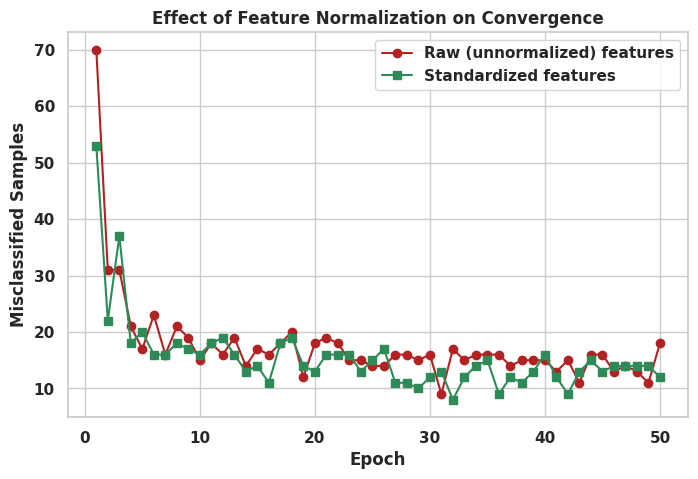

              Setting  Epochs to Converge (or cap)  Final Test Accuracy  Final Weight Norm ||w||
         Raw Features                           50               0.9636                   1.5011
Standardized Features                           50               0.9636                   0.3684


In [ ]:

def train_perceptron_track(X_tr, y_tr, lr=0.01, epochs=50):
    w = np.zeros(X_tr.shape[1])
    b = 0.0
    history = []
    for epoch in range(epochs):
        errors = 0
        for i in range(len(X_tr)):
            z = np.dot(X_tr[i], w) + b
            pred = 1 if z >= 0 else 0
            err = y_tr[i] - pred
            w = w + lr * err * X_tr[i]
            b = b + lr * err
            if err != 0:
                errors += 1
        history.append(errors)
        if errors == 0:
            break
    return w, b, history

w_raw, b_raw, hist_raw = train_perceptron_track(X_train_raw, y_train_raw, lr=0.01, epochs=50)
w_norm, b_norm, hist_norm = train_perceptron_track(X_train_norm, y_train_norm, lr=0.01, epochs=50)

acc_raw = evaluate(w_raw, b_raw, X_test_raw, y_test_raw)
acc_norm = evaluate(w_norm, b_norm, X_test_norm, y_test_norm)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(hist_raw) + 1), hist_raw, marker='o', label="Raw (unnormalized) features", color="firebrick")
plt.plot(range(1, len(hist_norm) + 1), hist_norm, marker='s', label="Standardized features", color="seagreen")
plt.title("Effect of Feature Normalization on Convergence", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
leg = plt.legend()
plt.setp(leg.get_texts(), fontweight='bold')
plt.grid(True)
plt.savefig("normalization_convergence_comparison.png", format="png", dpi=600, bbox_inches="tight")
plt.show()

norm_summary = pd.DataFrame({
    "Setting": ["Raw Features", "Standardized Features"],
    "Epochs to Converge (or cap)": [len(hist_raw), len(hist_norm)],
    "Final Test Accuracy": [round(acc_raw, 4), round(acc_norm, 4)],
    "Final Weight Norm ||w||": [round(float(np.linalg.norm(w_raw)), 4), round(float(np.linalg.norm(w_norm)), 4)]
})
print(norm_summary.to_string(index=False))


In [ ]:
import zipfile
import os

# Get a list of all .png files in the current directory
image_files = [f for f in os.listdir('.') if f.endswith('.png')]

# Define the name of the zip file
zip_filename = 'images.zip'

# Create a zip file and add all image files to it
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in image_files:
        zipf.write(file)

print(f"Successfully created '{zip_filename}' containing {len(image_files)} image files.")

Successfully created 'images.zip' containing 22 image files.


In [ ]:
"""
Perceptron Learning Algorithm - Logic Gates (AND, OR, NOT)

Task:
    Code the perceptron learning algorithm for OR, NOT and AND gates.
    Show the weights after each update.
    Plot the decision boundary after each weight update.

Design note:
    One small neuron class (`GateNeuron`) is reused for all three gates
    -- 2 inputs for AND/OR, 1 input for NOT. Every single weight
    *update* (not just every epoch) is logged with a full snapshot of
    (w, b) at that point, which is what lets us plot the boundary's
    evolution update-by-update rather than epoch-by-epoch.
    Uses only numpy (arrays/math) and matplotlib (plotting) -- no
    scikit-learn perceptron, so the learning rule itself is fully
    hand-written.
"""

import os
import math
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = "figures_gates"
os.makedirs(FIG_DIR, exist_ok=True)

class GateNeuron:
    """
    A single perceptron trained with the classical rule:
        z      = w . x + b
        y_hat  = 1 if z >= 0 else 0
        w     <- w + eta * (y - y_hat) * x
        b     <- b + eta * (y - y_hat)
    """

    def __init__(self, n_inputs: int, eta: float = 0.1, max_epochs: int = 20):
        self.w = np.zeros(n_inputs)
        self.b = 0.0
        self.eta = eta
        self.max_epochs = max_epochs
        self.update_history = []   # snapshot after every weight change

    def _activate(self, z):
        return 1 if z >= 0 else 0

    def predict_one(self, x_row):
        z = np.dot(self.w, x_row) + self.b
        return self._activate(z)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

    def train(self, X, y, gate_name=""):
        total_updates = 0
        for epoch in range(1, self.max_epochs + 1):
            epoch_errors = 0
            for x_row, target in zip(X, y):
                y_hat = self.predict_one(x_row)
                error = target - y_hat

                if error != 0:
                    self.w = self.w + self.eta * error * x_row
                    self.b = self.b + self.eta * error
                    epoch_errors += 1
                    total_updates += 1

                    print(f"[{gate_name}] epoch {epoch:2d} | "
                          f"input={x_row} target={target} pred={y_hat} | "
                          f"-> w={np.round(self.w, 3)}, b={round(self.b, 3)}")

                    self.update_history.append({
                        "update_no": total_updates,
                        "epoch": epoch,
                        "w": self.w.copy(),
                        "b": self.b,
                    })

            if epoch_errors == 0:
                print(f"[{gate_name}] Converged after epoch {epoch} "
                      f"({total_updates} total weight updates).\n")
                break
        else:
            print(f"[{gate_name}] Did not fully converge within "
                  f"{self.max_epochs} epochs ({total_updates} updates).\n")

        return self


GATES = {
    "AND": (np.array([[0, 0], [0, 1], [1, 0], [1, 1]]),
            np.array([0, 0, 0, 1])),
    "OR":  (np.array([[0, 0], [0, 1], [1, 0], [1, 1]]),
            np.array([0, 1, 1, 1])),
    "NOT": (np.array([[0], [1]]),
            np.array([1, 0])),
}


def plot_boundary_evolution(gate_name, X, y, update_history, n_inputs):
    n_updates = len(update_history)
    if n_updates == 0:
        print(f"[{gate_name}] No updates occurred (already linearly separable "
              f"at initial weights) -- nothing to plot.")
        return

    cols = min(4, n_updates)
    rows = math.ceil(n_updates / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, snap in enumerate(update_history):
        ax = axes_flat[idx]
        w, b = snap["w"], snap["b"]

        if n_inputs == 2:
            ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdYlGn",
                       edgecolor="black", s=90, zorder=3)
            xs = np.linspace(-0.5, 1.5, 200)
            if w[1] != 0:
                ys = -(w[0] * xs + b) / w[1]
                ax.plot(xs, ys, "b--", linewidth=1.5)
            elif w[0] != 0:
                ax.axvline(-b / w[0], color="b", linestyle="--", linewidth=1.5)
            ax.set_xlim(-0.5, 1.5)
            ax.set_ylim(-0.5, 1.5)
            ax.set_xlabel("x1", fontweight="bold")
            ax.set_ylabel("x2", fontweight="bold")
        else:  # 1-input gate (NOT)
            ax.scatter(X[:, 0], y, c=y, cmap="RdYlGn", edgecolor="black", s=90, zorder=3)
            if w[0] != 0:
                ax.axvline(-b / w[0], color="b", linestyle="--", linewidth=1.5)
            ax.set_xlim(-0.5, 1.5)
            ax.set_ylim(-0.5, 1.5)
            ax.set_xlabel("x1", fontweight="bold")
            ax.set_ylabel("target", fontweight="bold")

        ax.set_title(f"Update {snap['update_no']} (epoch {snap['epoch']})\n"
                      f"w={np.round(w, 2)}, b={round(b, 2)}", fontsize=9)

    for j in range(n_updates, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{gate_name} Gate - Decision Boundary After Each Weight Update",
                 fontsize=13)
    plt.tight_layout()
    fname = f"{FIG_DIR}/{gate_name.lower()}_boundary_evolution.png"
    plt.savefig(fname, dpi=600)
    plt.close()
    print(f"[{gate_name}] Saved boundary-evolution plot -> {fname}\n")


def main():
    for gate_name, (X, y) in GATES.items():
        print(f"\n========== TRAINING {gate_name} GATE ==========")
        n_inputs = X.shape[1]
        neuron = GateNeuron(n_inputs=n_inputs, eta=0.1, max_epochs=20)
        neuron.train(X, y, gate_name=gate_name)

        preds = neuron.predict(X)
        print(f"[{gate_name}] Final weights: w={np.round(neuron.w, 3)}, "
              f"b={round(neuron.b, 3)}")
        print(f"[{gate_name}] Predictions on truth table: {preds.tolist()} "
              f"(expected {y.tolist()})")

        plot_boundary_evolution(gate_name, X, y, neuron.update_history, n_inputs)


if __name__ == "__main__":
    main()


========== TRAINING AND GATE ==========
[AND] epoch  1 | input=[0 0] target=0 pred=1 | -> w=[0. 0.], b=-0.1
[AND] epoch  1 | input=[1 1] target=1 pred=0 | -> w=[0.1 0.1], b=0.0
[AND] epoch  2 | input=[0 0] target=0 pred=1 | -> w=[0.1 0.1], b=-0.1
[AND] epoch  2 | input=[0 1] target=0 pred=1 | -> w=[0.1 0. ], b=-0.2
[AND] epoch  2 | input=[1 1] target=1 pred=0 | -> w=[0.2 0.1], b=-0.1
[AND] epoch  3 | input=[0 1] target=0 pred=1 | -> w=[0.2 0. ], b=-0.2
[AND] epoch  3 | input=[1 0] target=0 pred=1 | -> w=[0.1 0. ], b=-0.3
[AND] epoch  3 | input=[1 1] target=1 pred=0 | -> w=[0.2 0.1], b=-0.2
[AND] Converged after epoch 4 (8 total weight updates).

[AND] Final weights: w=[0.2 0.1], b=-0.2
[AND] Predictions on truth table: [0, 0, 0, 1] (expected [0, 0, 0, 1])
[AND] Saved boundary-evolution plot -> figures_gates/and_boundary_evolution.png


========== TRAINING OR GATE ==========
[OR] epoch  1 | input=[0 0] target=0 pred=1 | -> w=[0. 0.], b=-0.1
[OR] epoch  1 | input=[0 1] target=1 pred=0 |

AND Gate Decision Boundary Evolution:


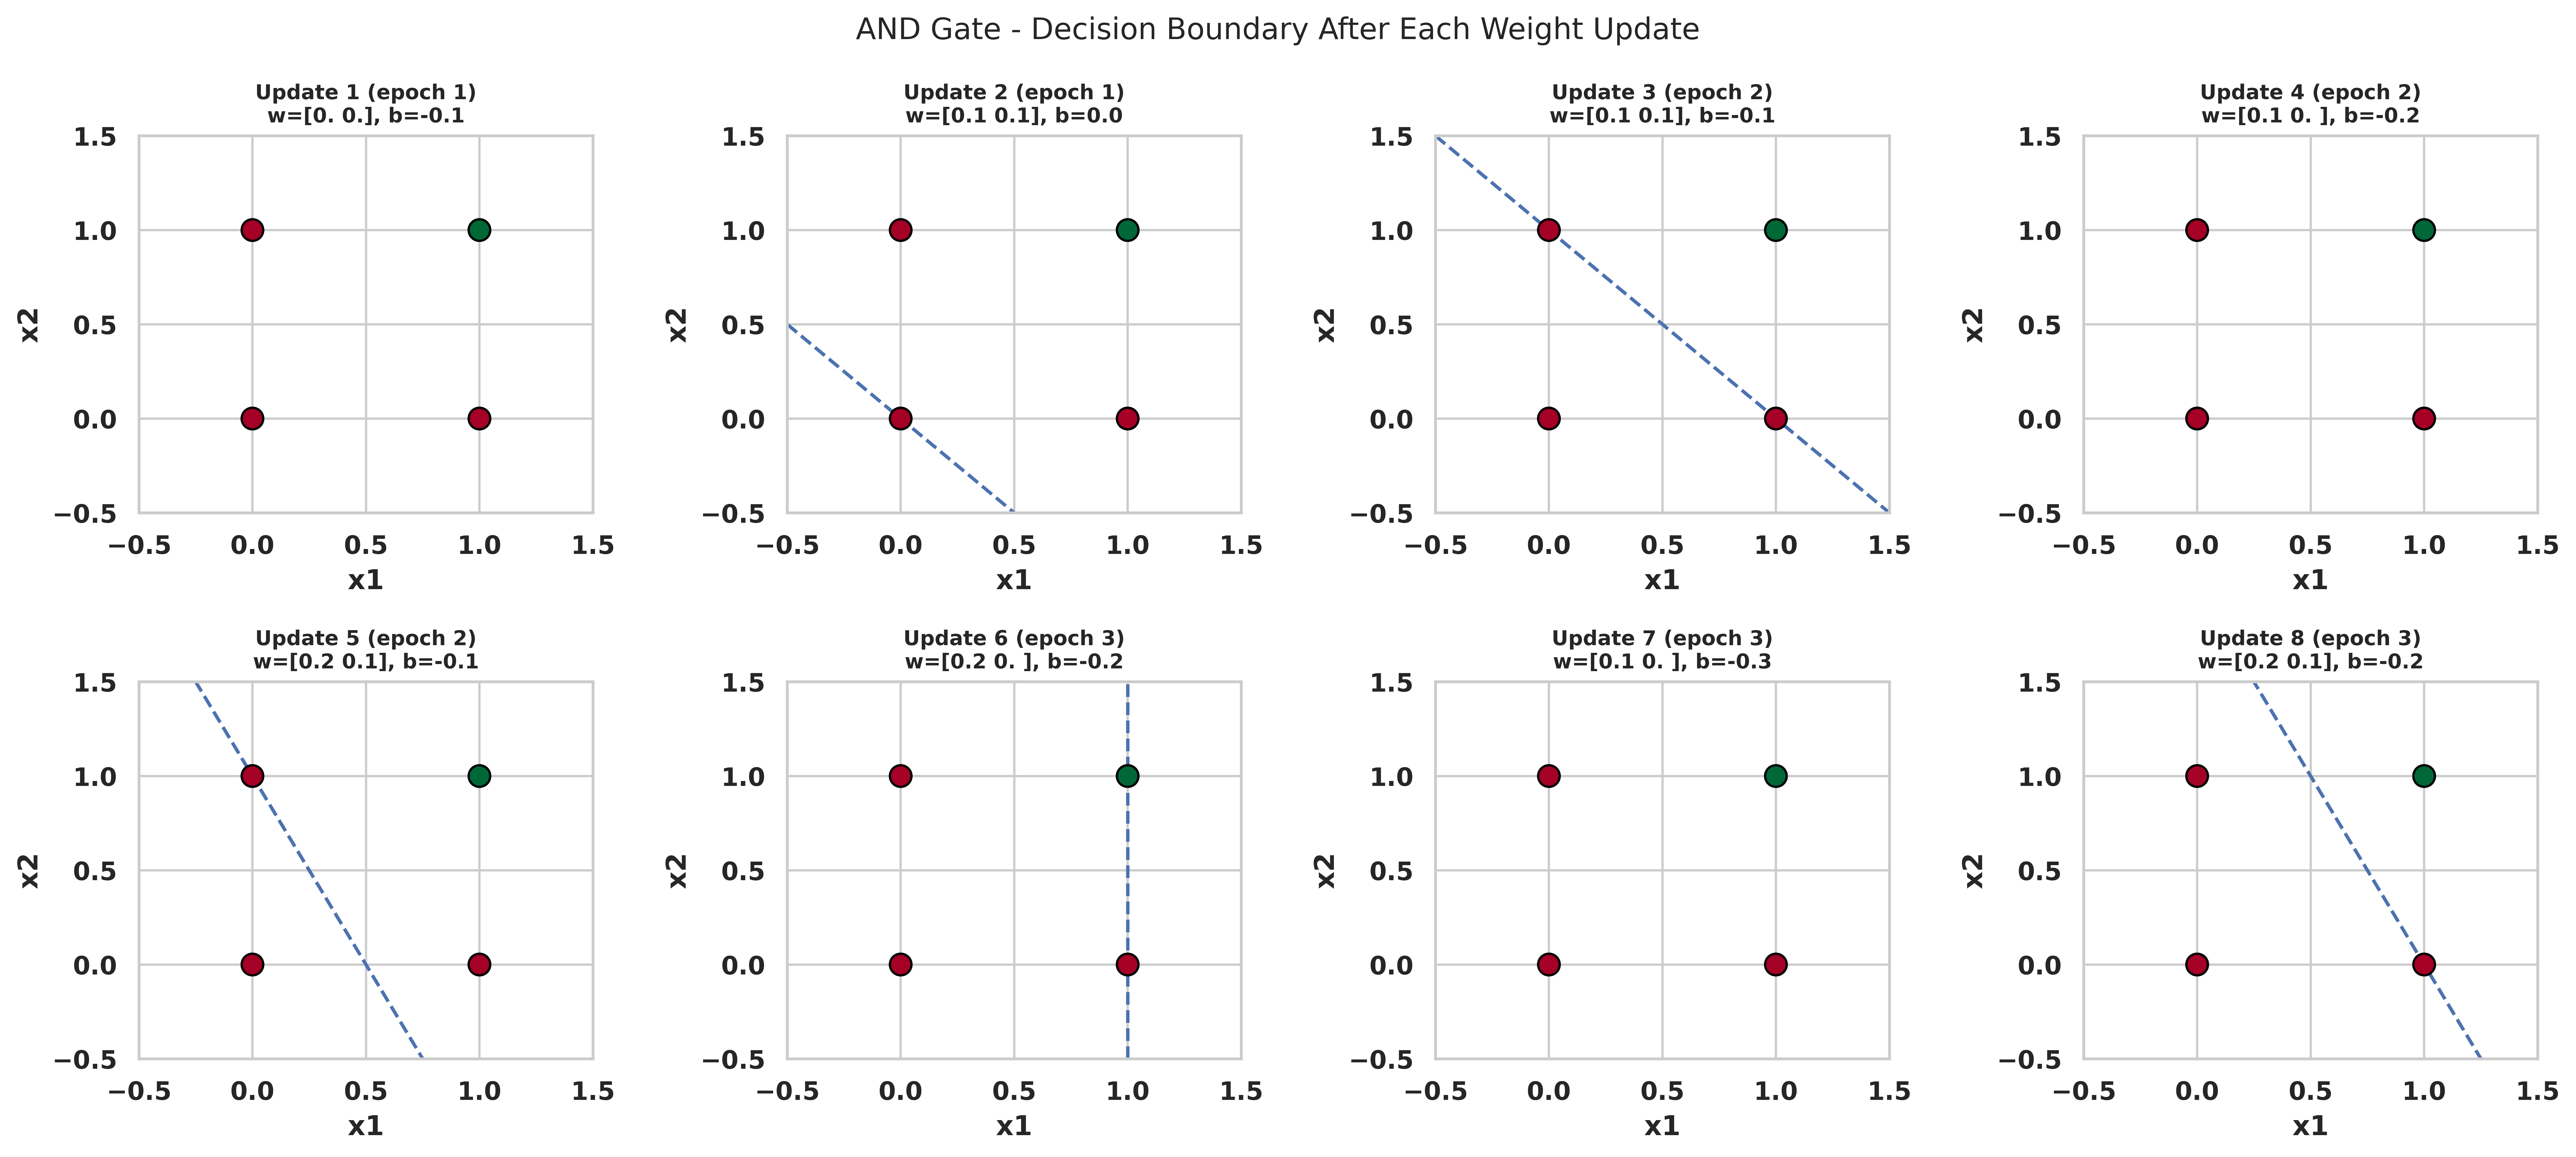


OR Gate Decision Boundary Evolution:


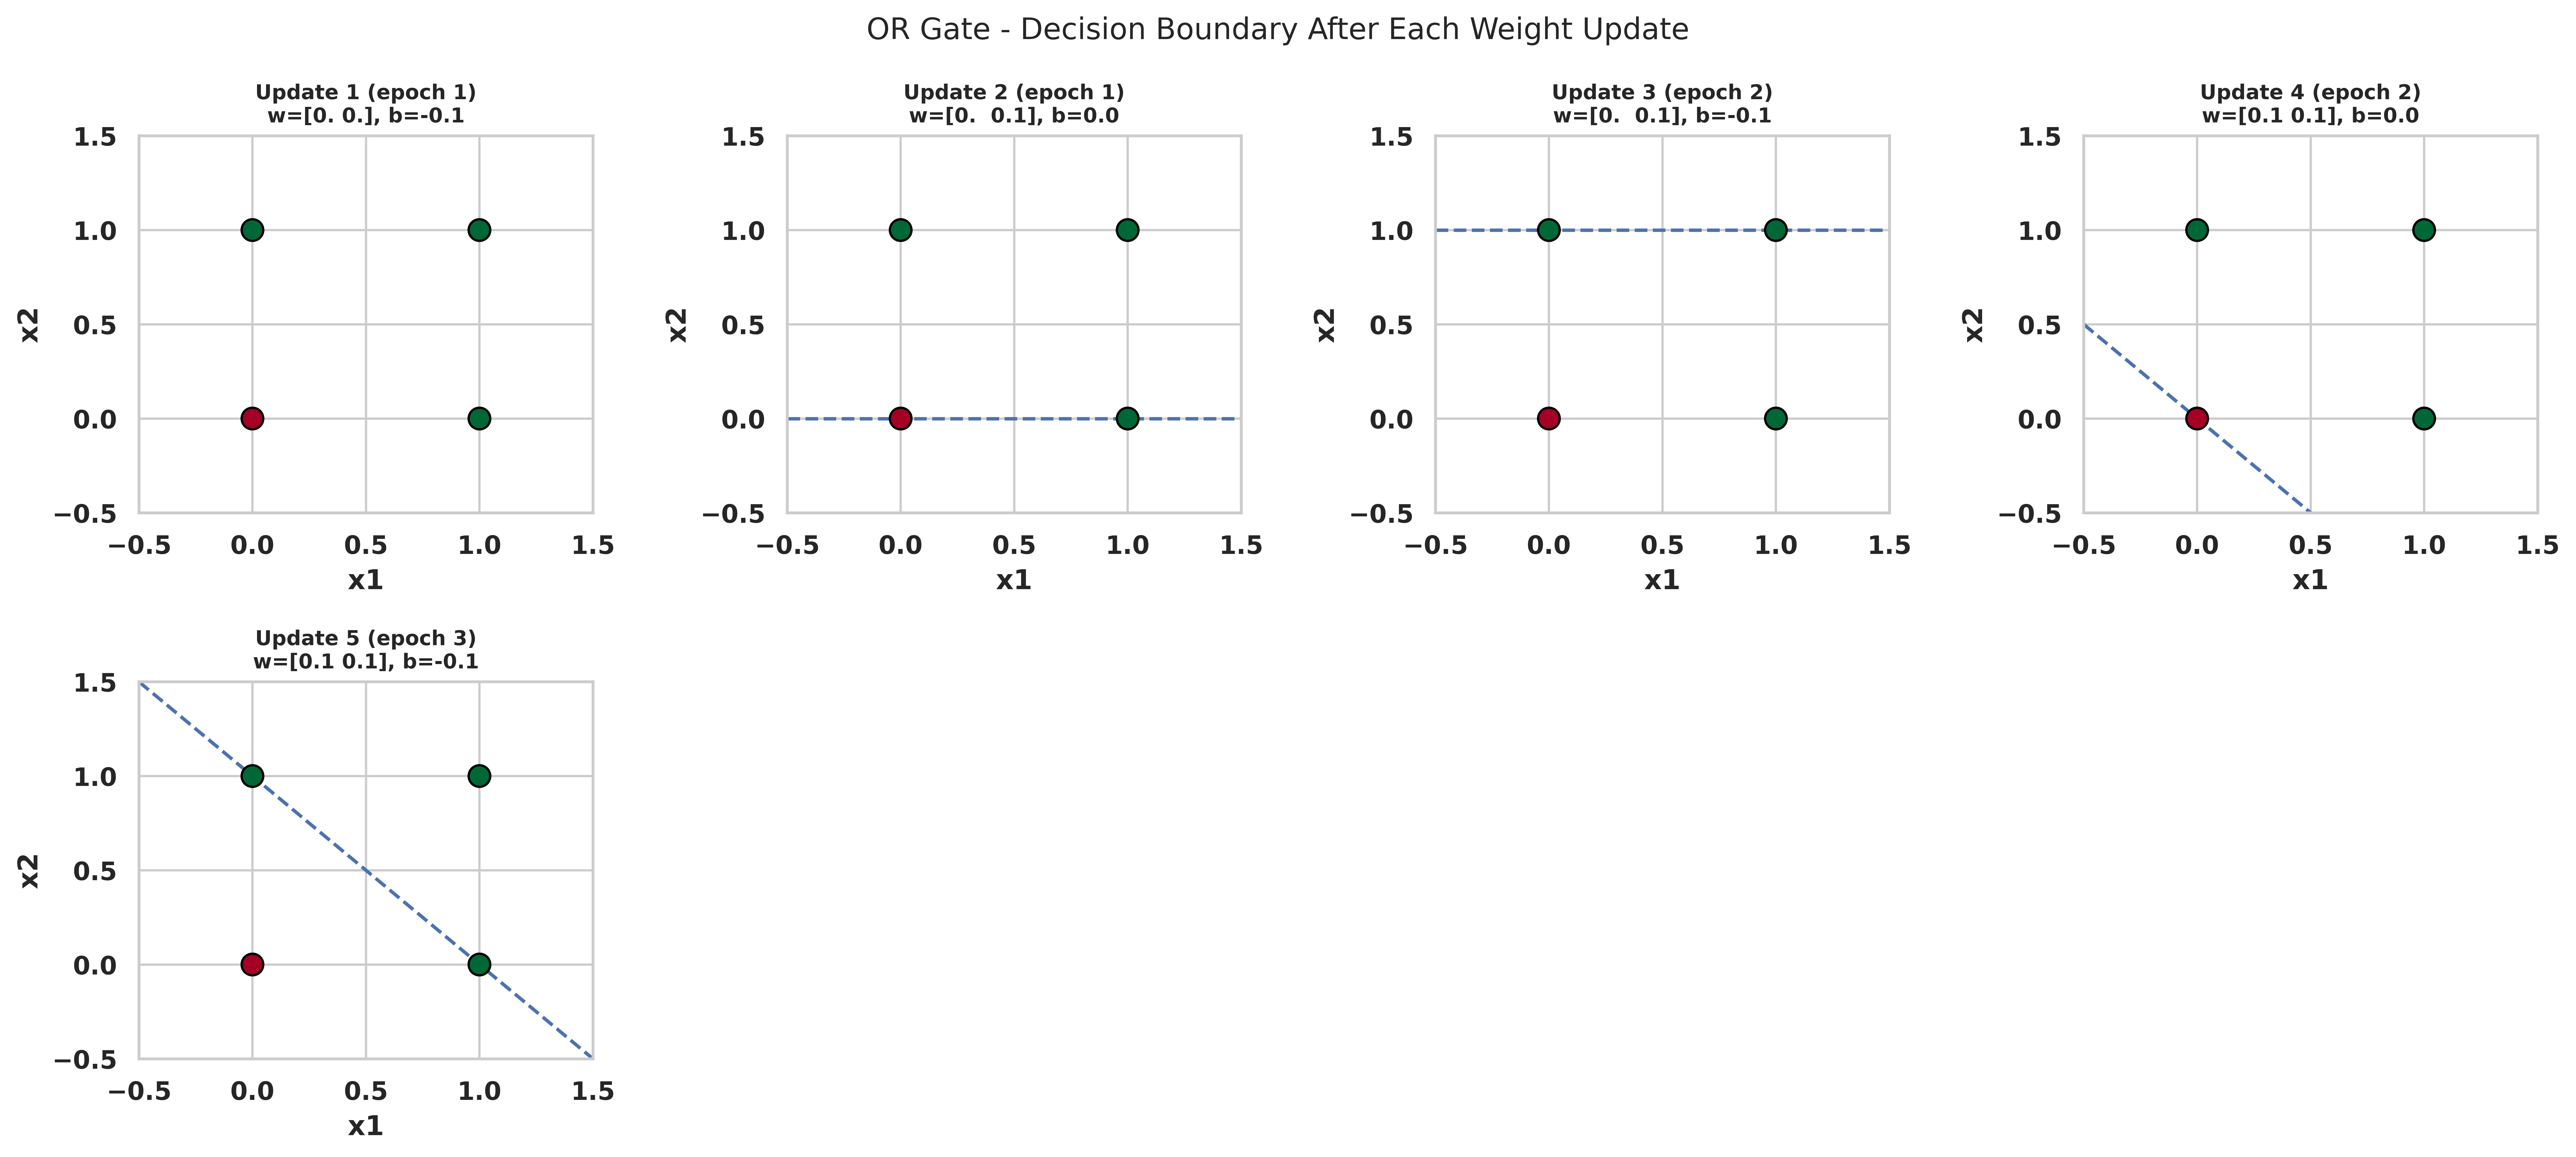


NOT Gate Decision Boundary Evolution:


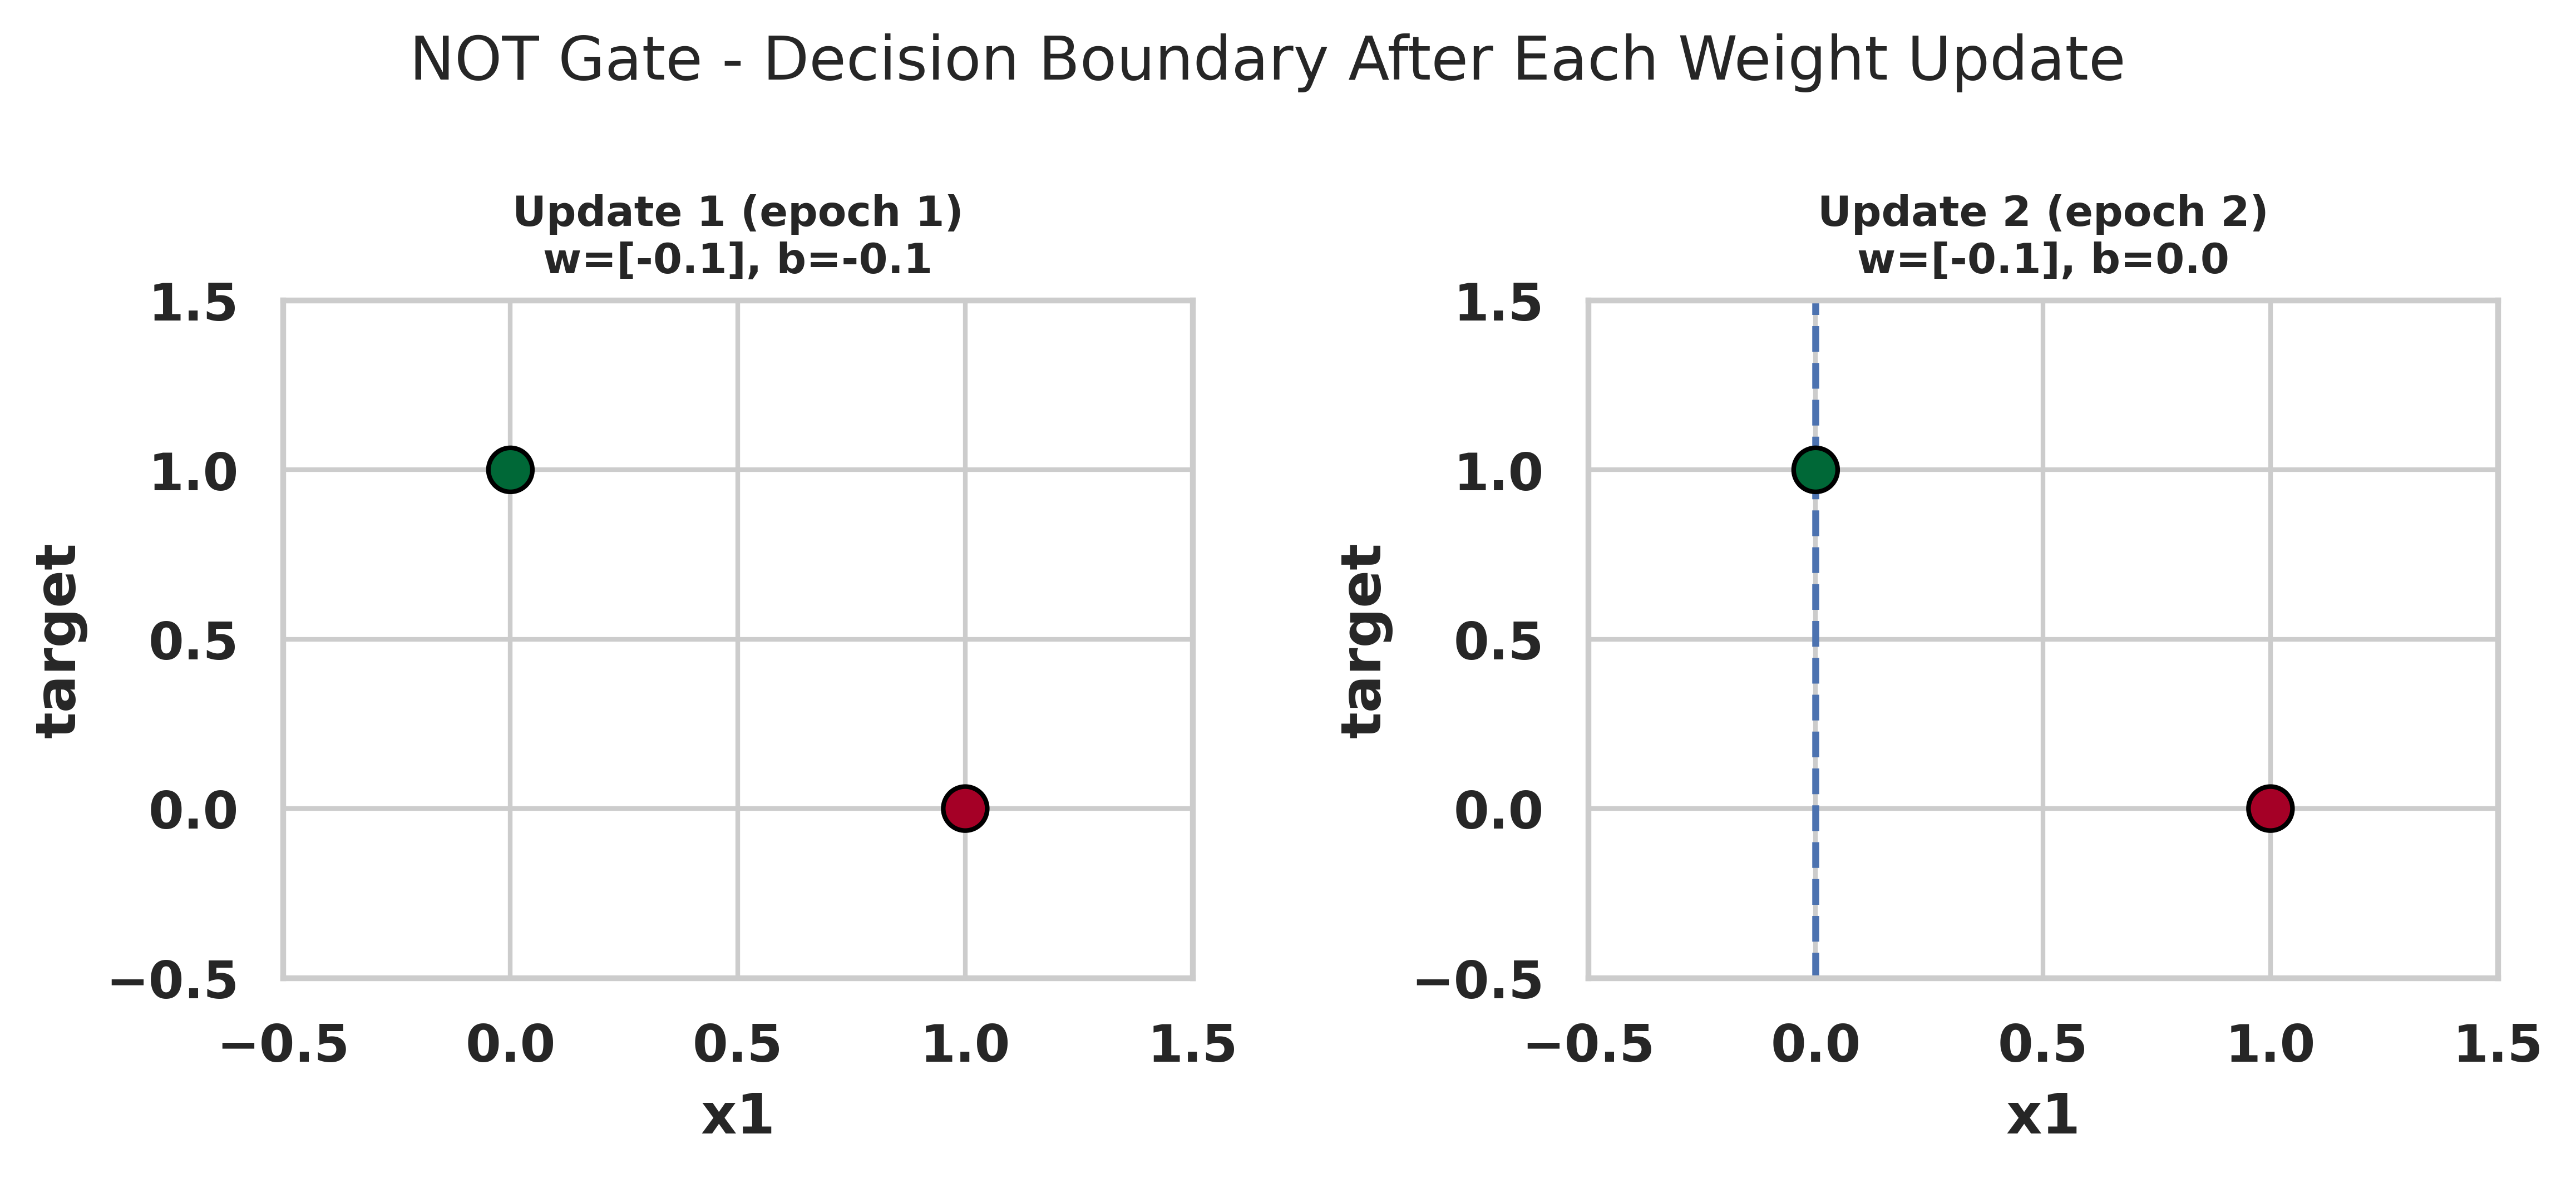

In [ ]:
from IPython.display import Image, display

# Display the generated images
print("AND Gate Decision Boundary Evolution:")
display(Image('figures_gates/and_boundary_evolution.png'))

print("\nOR Gate Decision Boundary Evolution:")
display(Image('figures_gates/or_boundary_evolution.png'))

print("\nNOT Gate Decision Boundary Evolution:")
display(Image('figures_gates/not_boundary_evolution.png'))